# Assignment 1



## Dataset Provenance and Characteristics

This project utilizes the ADS509/full_experiment_labels dataset, sourced from the Hugging Face Hub. It is a text classification dataset containing a collection of opinionated text snippets and social commentary, partitioned into standard training, validation, and testing splits (train_data.csv, valid_data.csv, and test_data.csv). The primary objective of this dataset is to facilitate natural language processing (NLP) experiments—specifically by providing raw textual features mapped to corresponding experimental labels. The data has been extracted from its original Parquet format into CSVs to ensure accessibility and reproducibility across the team.

The dataset consists of social media comments focused on political discourse. Data was collected by querying for "politics" or "US Politics" across five distinct online platforms: YouTube, Hacker News, MetaFilter, Reddit, and BlueSky. The collection timeframe spans from 2024 to mid-February 2026. Because of varying platform traffic and API rate limits (e.g., Reddit limits being hit in just two weeks), the exact date ranges vary by source. To ensure rich contextual threads, posts with fewer than 10 comments were ignored, and a maximum of 300 comments were pulled from any single post.

The dataset features five distinct classes, mapping conversational intents to integer labels:

- Neutral (0): Clarifying questions, meta-commentary, or off-topic remarks.
- Opinion (1): Value judgments or stances without substantial reasoning.
- Argumentative (2): Specific claims or assertions supported by reasoning, evidence, or anecdotes aiming to persuade.
- Expressive (3): Emotional reactions, sarcasm, venting, or performative agreement/disagreement.
- Informational (4): Sharing facts, data, links, or context with low emotional affect.

The labeling process utilized a hybrid Human-AI consensus approach. An initial sample of 100 comments was independently labeled by two human annotators, compared, and revised to establish ground truth. The remaining dataset was annotated using a few-shot prompting strategy via Batch APIs with three Large Language Models: Gemini Flash 3, ChatGPT 5.1, and Claude Haiku 4.5. The prompt included 10 correct examples and 10 corrected examples. Only comments that achieved agreement from at least two of the three models were retained for the final dataset.

The creators of the dataset applied several initial cleaning steps before publication. Approximately 2,000 to 3,000 duplicate comments and all NaN values were removed. The text underwent standardization: emojis were converted into text representations, all text was lowercased, HTML artifacts were stripped, URLs were replaced with a generic [URL] tag, and escaped characters (e.g., &quot;) were converted back to standard text.

The resulting dataset contains a total of 70,383 examples, partitioned into standard splits:

- Training Set: 49,268 examples
- Validation Set: 10,557 examples
- Testing Set: 10,558 examples

# Imports

In [7]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost gensim spacy hmmlearn wordcloud nltk
import sys
!{sys.executable} -m spacy download en_core_web_md

from IPython.display import clear_output
clear_output()

In [2]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import spacy
import gensim.downloader as api
import nltk

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.feature_extraction.text import (
    CountVectorizer, 
    TfidfVectorizer, 
    HashingVectorizer
)
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier
from hmmlearn import hmm

from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    classification_report,
    precision_recall_fscore_support
)

from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from wordcloud import WordCloud



# EDA

In [13]:
df = pd.read_csv('../data/train_data.csv')

print("Columns in the dataset:", df.columns.tolist())
print("\nUnique labels:", df['label'].unique()) 
print("\nFirst row preview:\n", df.iloc[0])

Columns in the dataset: ['text', 'label']

Unique labels: [3 2 1 4 0]

First row preview:
 text     thank you!!!!!!!!!!!
label                       3
Name: 0, dtype: object


In [5]:
df.head()

,text,label
0,thank you!!!!!!!!!!!,3
1,of course they are attacking her but are perfe...,2
2,i am not aware of the us having the ability in...,1
3,"these senators are so funny, in the preceding ...",2
4,naye face_with_tears_of_joy face_with_tears_of...,3


1    15343
3    15333
2    11121
0     3949
4     3522
Name: label, dtype: int64
1    0.311419
3    0.311216
2    0.225725
0    0.080153
4    0.071487
Name: label, dtype: float64


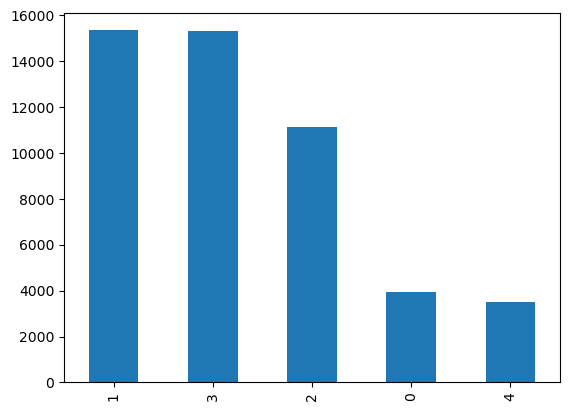

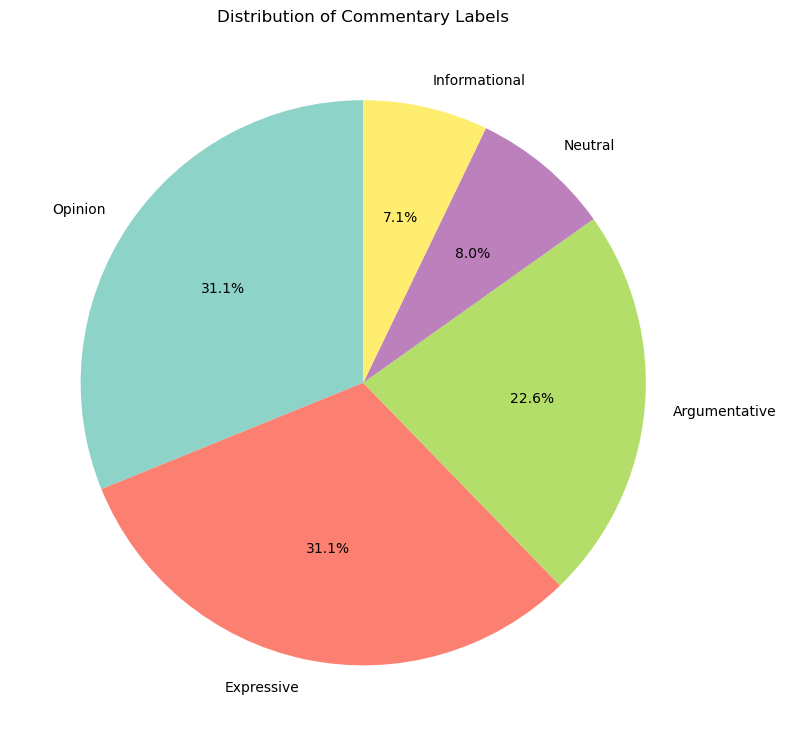

In [14]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True))

df['label'].value_counts().plot(kind='bar')

plt.show()

label_mapping = {
    0: 'Neutral',
    1: 'Opinion',
    2: 'Argumentative',
    3: 'Expressive',
    4: 'Informational'
}

counts = df['label'].value_counts()

counts.index = counts.index.map(label_mapping)

counts.plot(
    kind='pie', 
    autopct='%1.1f%%', 
    startangle=90, 
    figsize=(8, 8),
    cmap='Set3' 
)

plt.title('Distribution of Commentary Labels')
plt.ylabel('')
plt.tight_layout()
plt.show()

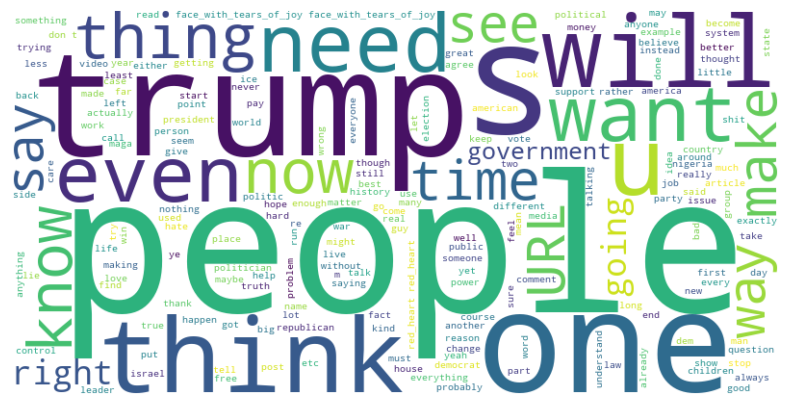

In [16]:
corpus = df['text'].dropna().astype(str).tolist()

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(corpus))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

## TDF-IDF

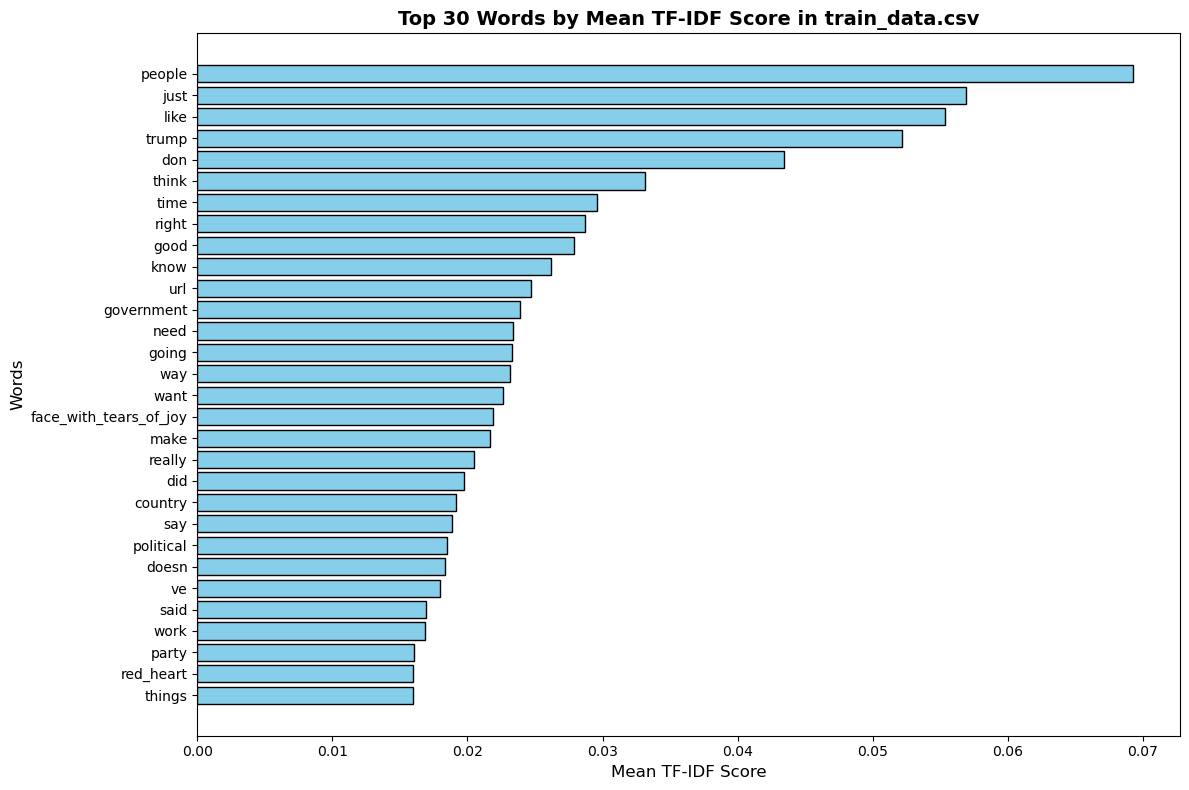

In [23]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=30)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['text'])

feature_names = tfidf_vectorizer.get_feature_names_out()

mean_tfidf_scores = tfidf_matrix.mean(axis=0).A1

tfidf_df = pd.DataFrame({'Word': feature_names, 'Mean_TFIDF': mean_tfidf_scores})

tfidf_df = tfidf_df.sort_values(by='Mean_TFIDF', ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(tfidf_df['Word'], tfidf_df['Mean_TFIDF'], color='skyblue', edgecolor='black')

plt.xlabel('Mean TF-IDF Score', fontsize=12)
plt.ylabel('Words', fontsize=12)
plt.title('Top 30 Words by Mean TF-IDF Score in train_data.csv', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Cleanup and Normalization

In [26]:
print(df['text'])

0                                     thank you!!!!!!!!!!!
1        of course they are attacking her but are perfe...
2        i am not aware of the us having the ability in...
3        these senators are so funny, in the preceding ...
4        naye face_with_tears_of_joy face_with_tears_of...
                               ...                        
49263    what’s the difference between seizing an oil t...
49264    mulberry ([URL] , that perfectly describes new...
49265    yeah. under erdogan, turkey's gdp grew like cr...
49266                             it should never be funny
49267    those sneaky freeloaders, materially improving...
Name: text, Length: 49268, dtype: object


Removal of non-alphabetical characters, lowercasing, removing stopwords, and stemming.

In [20]:
nltk.download('stopwords')

corpus = []
ps = PorterStemmer()
sw = set(stopwords.words('english'))
for i in range(0, df['text'].size):
    # get review and remove non alpha chars
    review = re.sub('[^a-zA-Z]', ' ', df['text'][i])
    # to lower-case
    review = review.lower()
    # split into tokens, apply stemming and remove stop words
    review = ' '.join([ps.stem(w) for w in review.split() if w not in sw])
    corpus.append(review)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Utilizador\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Pre-processing Choices Justification

In this step, we apply several text normalization techniques to clean our social media commentary data:
* **Lowercasing & Non-alphabetical Removal:** Standardizes the text and removes noisy punctuation that doesn't contribute to the core sentiment or argument.
* **Stopword Removal:** Filters out highly common but semantically uninformative words (like 'the', 'is', 'and') to reduce noise and dimensionality.
* **Stemming (PorterStemmer):** We chose the `PorterStemmer` for its computational efficiency and simplicity. Social media data is often highly informal, noisy, and prone to grammatical errors. The Porter Stemmer uses a well-established set of heuristic rules to strip common morphological endings, collapsing variations of words (e.g., "argue", "arguing", "argued") into a single base feature. While lemmatization is an alternative, it requires accurate Part-of-Speech (POS) tagging which often struggles with internet slang, making the lightweight and robust PorterStemmer a sensible choice for this dataset.

### Wordcloud after pre-processing

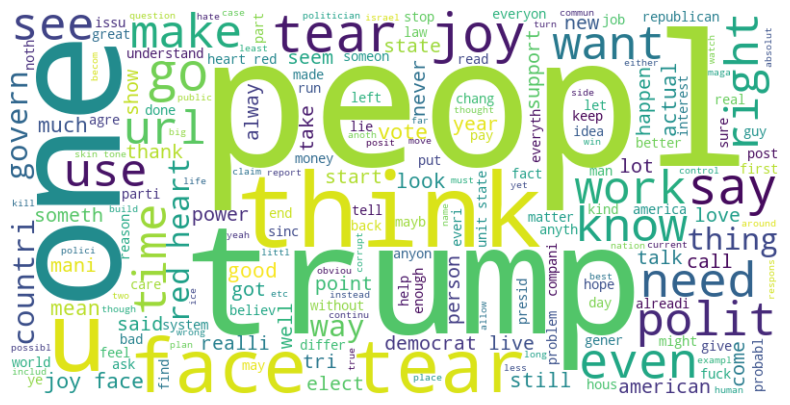

In [21]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(corpus))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

### Wordcloud for each label.

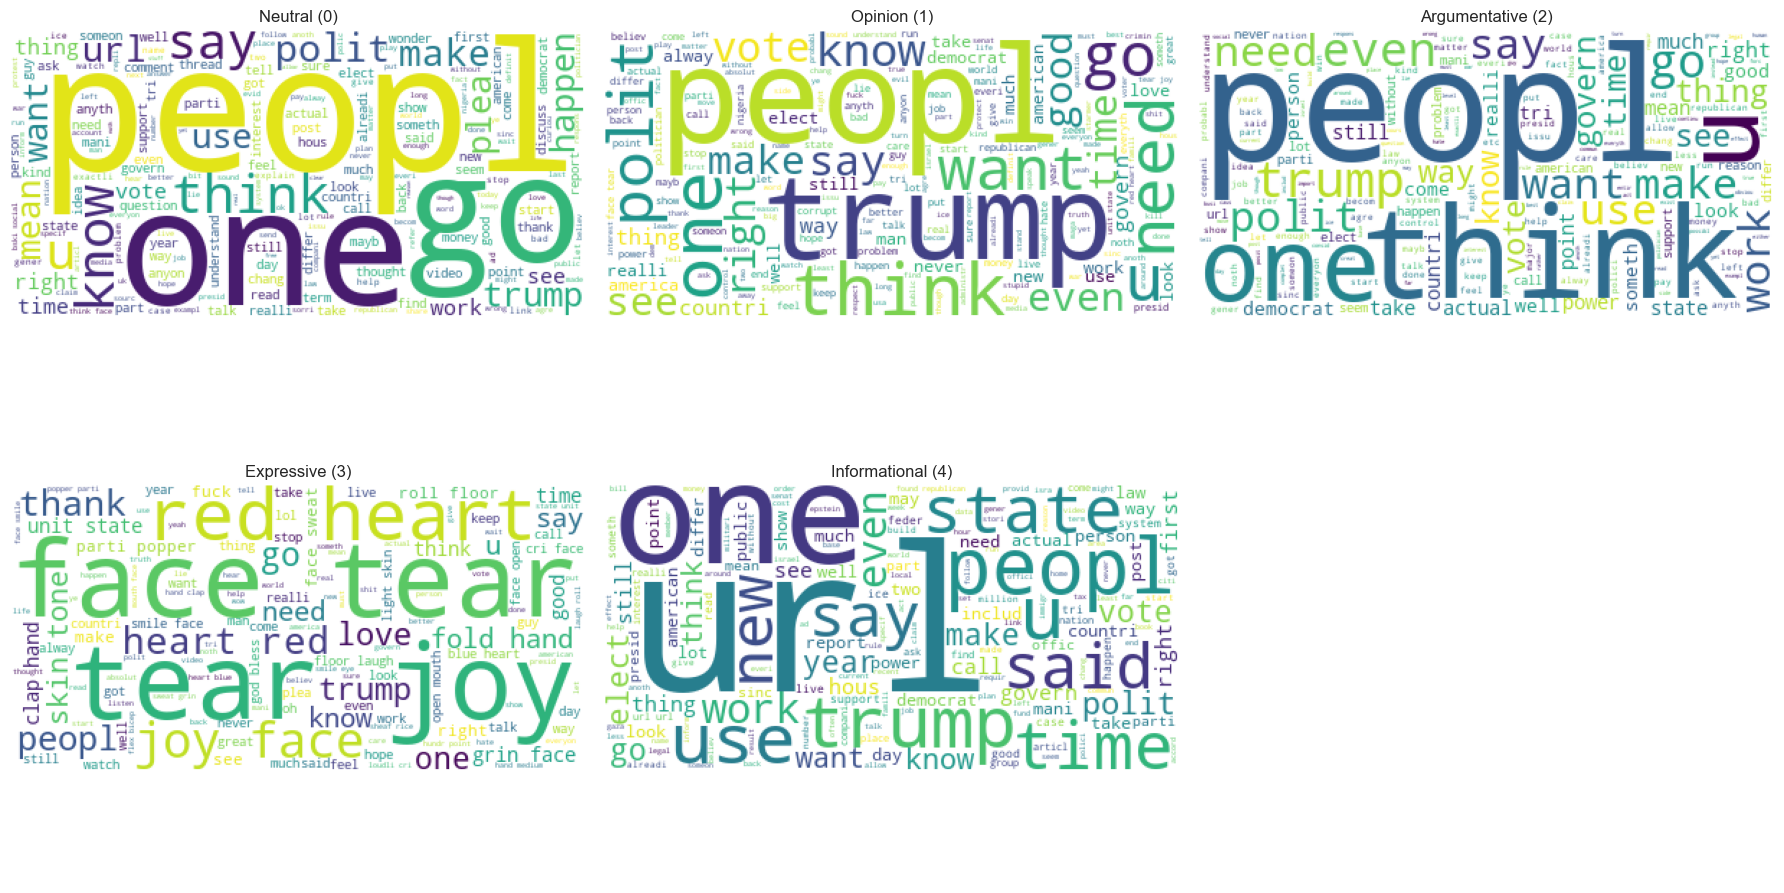

In [29]:
label_names = {
    0: 'Neutral',
    1: 'Opinion',
    2: 'Argumentative',
    3: 'Expressive',
    4: 'Informational'
}

texts_by_label = {
    label: ' '.join([review for review, y in zip(corpus, df['label']) if y == label])
    for label in label_names
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (label, name) in enumerate(label_names.items()):
    text = texts_by_label[label]
    if text.strip():
        wc = WordCloud(background_color='white').generate(text)
        axes[i].imshow(wc)
    else:
        axes[i].text(0.5, 0.5, 'No data for this label', ha='center', va='center')
    axes[i].set_title(f"{name} ({label})")
    axes[i].axis('off')

# Hide the unused subplot (6th axis)
for j in range(len(label_names), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Why CountVectorizer for the baseline?

We use **CountVectorizer** to build a Bag-of-Words baseline because it is simple, transparent, and pairs naturally with **Multinomial Naive Bayes**, which models token counts directly. This gives us a low-complexity reference point against which we can compare stronger weighted representations such as TF-IDF. If TF-IDF and linear models outperform this setup, we can attribute part of the gain to better term weighting rather than only to the classifier choice.

## Generating Data Set

In [31]:
vectorizer = CountVectorizer(max_features = 1500)
X = vectorizer.fit_transform(corpus).toarray()
y = df['label']

print(X.shape, y.shape)

(49268, 1500) (49268,)


In [32]:
idx = 100  # 124th review (0-based index)

print('Original review:')
print(df['text'][idx])
print('\nPreprocessed review:')
print(corpus[idx])

print('\nBag-of-Words vector (full):')
print(X[idx])

feature_names = vectorizer.get_feature_names_out()
non_zero_indices = [j for j, v in enumerate(X[idx]) if v > 0]

print('\nNon-zero features in the 124th review:')
for j in non_zero_indices:
    print(f"{feature_names[j]}: {X[idx][j]}")

Original review:
so even autocomplete is smart enough to understand that "not politically correct" just means racism

Preprocessed review:
even autocomplet smart enough understand polit correct mean racism

Bag-of-Words vector (full):
[0 0 0 ... 0 0 0]

Non-zero features in the 124th review:
correct: 1
enough: 1
even: 1
mean: 1
polit: 1
racism: 1
smart: 1
understand: 1


## Training Classifiers

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

print("\nLabel distribution in the training set:")
print(y_train.value_counts())

print("\nLabel distribution in the test set:")
print(y_test.value_counts())

(39414, 1500) (39414,)
(9854, 1500) (9854,)

Label distribution in the training set:
1    12267
3    12225
2     8945
0     3178
4     2799
Name: label, dtype: int64

Label distribution in the test set:
3    3108
1    3076
2    2176
0     771
4     723
Name: label, dtype: int64


## Baseline Model: Multinomial Naive Bayes with Bag-of-Words

In [34]:
clf = MultinomialNB()
clf.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [35]:
y_pred = clf.predict(X_test)
print(y_pred)

[3 3 2 ... 1 4 3]


In [36]:
# confusion matrix
print(confusion_matrix(y_test, y_pred))

# multiclass metrics
print('Accuracy: ', accuracy_score(y_test, y_pred))
print('Precision (weighted):', precision_score(y_test, y_pred, average='weighted', zero_division=0))
print('Recall (weighted):   ', recall_score(y_test, y_pred, average='weighted', zero_division=0))
print('F1 (weighted):       ', f1_score(y_test, y_pred, average='weighted', zero_division=0))

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Neutral', 'Opinion', 'Argumentative', 'Expressive', 'Informational'], zero_division=0))

[[ 111  343  160   98   59]
 [ 100 1968  624  330   54]
 [ 114  700 1139   41  182]
 [  85 1207  205 1577   34]
 [  57  159  173   35  299]]
Accuracy:  0.5169474325147149
Precision (weighted): 0.542208504160936
Recall (weighted):    0.5169474325147149
F1 (weighted):        0.5154316147042292

Classification Report:
               precision    recall  f1-score   support

      Neutral       0.24      0.14      0.18       771
      Opinion       0.45      0.64      0.53      3076
Argumentative       0.50      0.52      0.51      2176
   Expressive       0.76      0.51      0.61      3108
Informational       0.48      0.41      0.44       723

     accuracy                           0.52      9854
    macro avg       0.48      0.45      0.45      9854
 weighted avg       0.54      0.52      0.52      9854



## Feature Extraction and Modeling Pipeline

To rigorously evaluate the ADS509 dataset, we implemented an automated pipeline testing various sparse and dense feature representations against traditional machine learning classifiers.

### Pre-processing

We used the previously mentioned pre-processing (regex alphabetic cleaning, lowercasing, Porter Stemming, and NLTK stopword removal) but only for the following methods: **BoW (Bag of Words), TF-IDF, N-Grams, Hashing, LSA, and CustomW2V**, because these statistical and count-based models rely on standardized, root-form tokens to reduce vocabulary size and group variations of words together. 

Conversely, we explicitly *bypassed* this custom pre-processing for the other extractors:
* **Pre-trained Dense Embeddings (Word2Vec / FastText via spaCy):** These models expect raw, natural sentences. Applying aggressive stemming or stopword removal strips away the syntactic context they need to properly map words to their pre-calculated vector spaces.
* **Linguistic:** Must receive the raw, untouched text to function correctly. Stripping the text would destroy the punctuation (exclamation and question marks) and capitalization metrics required by the Linguistic extractor.

### Embedding Representation Choices

To determine the most effective way to represent our text data, the pipeline was configured to test 10 distinct feature extraction strategies across three main categories:

1.  **Sparse / Statistical Vectors:** * Standard Bag of Words (`CountVectorizer`).
    * TF-IDF to weigh terms by document frequency.
    * N-Grams (capturing 1-word to 3-word phrases via TF-IDF) to capture localized sequence context.
    * Hashing Vectorizer (capped at 10,000 features) for highly memory-efficient, stateless text mapping.
2.  **Dense / Semantic Embeddings:**
    * **LSA (Latent Semantic Analysis):** Applying TruncatedSVD (100 components) over TF-IDF arrays to reduce dimensionality and find latent topics.
    * **Pre-trained Models:** Leveraging spaCy's `en_core_web_md` to generate document-level averages of pre-trained Word2Vec and FastText embeddings.
    * **Custom Word2Vec:** Training a `gensim` Word2Vec model from scratch strictly on the training corpus (vector size 100, window 5) to capture domain-specific semantic relationships.
3.  **Engineered Features:**
    * **Linguistic:** Extracting structural metadata (document length, word count, punctuation density, and capitalization ratios).

### Model Evaluation Strategy

Our evaluation strategy paired the above representations against a matrix of 8 diverse classifiers: Logistic Regression, One-vs-Rest SVM, Naive Bayes, Sentiment LDA, Gaussian HMM, k-NN, XGBoost, and AdaBoost. 

The execution loop was designed with the following rigorous evaluation protocols:

* **Dynamic Pipeline Construction:** The script dynamically builds `scikit-learn` Pipelines for each valid combination, injecting `FunctionTransformers` where necessary (e.g., converting sparse matrices to dense arrays for HMM, or ensuring absolute values for Naive Bayes when using Hashing).
* **Performance Metrics:** Models are evaluated on an isolated validation set (`valid_data.csv`). The primary ranking metric is the **weighted F1-Score**, alongside Accuracy, Precision, and Recall, to account for potential class imbalances.
* **Computational Tracking:** Both training time and inference (validation) time are explicitly timed and logged to evaluate the real-world operational cost of each model-feature combination.
* **Resilient Execution:** Because training this many combinations is computationally expensive, the script utilizes a checkpointing system. It saves individual results to `pipeline_results.csv` immediately after each successful run and skips already-completed combinations if the script is restarted. Upon completion, the entire matrix is sorted to reveal the top-performing architectures based on F1-Score.

### Quantifying the Sparse Feature Space (TF-IDF)
Before running our automated modeling pipeline, we isolate our primary sparse representation (TF-IDF) to quantify the exact size of the feature space it generates on the training corpus.

In [38]:
train_df_demo = pd.read_csv('../data/train_data.csv')
train_df_demo = train_df_demo.dropna(subset=['text'])

tfidf_demo = TfidfVectorizer()

X_train_tfidf = tfidf_demo.fit_transform(train_df_demo['text'])

print(f"Number of training examples: {X_train_tfidf.shape[0]}")
print(f"Size of the TF-IDF feature space (number of unique tokens/features): {X_train_tfidf.shape[1]}")

Number of training examples: 49268
Size of the TF-IDF feature space (number of unique tokens/features): 48189


In [ ]:
# ---------------------------------------------------------
# 1. Custom Transformers for Advanced Features
# ---------------------------------------------------------

class TextPreprocessor(BaseEstimator, TransformerMixin):
    """Applies Regex cleaning, Porter Stemming, and Stopword removal."""
    def __init__(self):
        # We initialize the stemmer and stopwords here so it only loads once
        nltk.download('stopwords', quiet=True)
        self.ps = PorterStemmer()
        self.sw = set(stopwords.words('english'))
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        cleaned_X = []
        # Using your exact logic, but generalized to work on batches of X
        for text in X:
            review = re.sub('[^a-zA-Z]', ' ', str(text))
            review = review.lower()
            review = ' '.join([self.ps.stem(w) for w in review.split() if w not in self.sw])
            cleaned_X.append(review)
        return np.array(cleaned_X)

class LinguisticFeatureExtractor(BaseEstimator, TransformerMixin):
    """Extracts style and linguistic features (punctuation, length, caps)."""
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        features = []
        for text in X:
            length = len(text)
            exclamations = text.count('!')
            questions = text.count('?')
            caps = sum(1 for c in text if c.isupper())
            words = len(text.split())
            
            features.append([
                length, 
                words, 
                exclamations / max(length, 1), 
                questions / max(length, 1), 
                caps / max(length, 1)
            ])
        return np.array(features)

class DenseEmbeddingTransformer(BaseEstimator, TransformerMixin):
    """Loads pre-trained Word2Vec or FastText and averages them per document in FAST BATCHES."""
    def __init__(self, model_type='word2vec'):
        self.model_type = model_type
        self.nlp = None
        
    def fit(self, X, y=None):
        if self.nlp is None:
            self.nlp = spacy.load("en_core_web_md", disable=["tok2vec", "tagger", "parser", "attribute_ruler", "lemmatizer", "ner"])
        return self
        
    def transform(self, X):
        return np.array([doc.vector for doc in self.nlp.pipe(X, batch_size=500)])


class CustomEmbeddingTransformer(BaseEstimator, TransformerMixin):
    """Builds Word2Vec embeddings from scratch on the training text and averages them."""
    def __init__(self, vector_size=100, window=5, min_count=2):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.model = None
        
    def fit(self, X, y=None):
        from gensim.models import Word2Vec
        sentences = [str(text).lower().split() for text in X]
        self.model = Word2Vec(sentences, vector_size=self.vector_size, window=self.window, min_count=self.min_count, workers=4)
        return self
        
    def transform(self, X):
        features = []
        for text in X:
            words = str(text).lower().split()
            word_vecs = [self.model.wv[w] for w in words if w in self.model.wv]
            
            if len(word_vecs) > 0:
                features.append(np.mean(word_vecs, axis=0))
            else:
                features.append(np.zeros(self.vector_size))
        return np.array(features)

class HMMClassifierWrapper(BaseEstimator):
    """Wraps hmmlearn to work within a scikit-learn pipeline for 5 classes."""
    def __init__(self, n_components=5):
        self.n_components = n_components
        self.models = {}
        
    def fit(self, X, y):
        classes = np.unique(y)
        for c in classes:
            X_c = X[y == c]
            model = hmm.GaussianHMM(n_components=self.n_components, covariance_type="diag", n_iter=10)
            if X_c.shape[0] > 0:
                model.fit(X_c)
                self.models[c] = model
        return self
        
    def predict(self, X):
        predictions = []
        for sample in X:
            sample = sample.reshape(1, -1)
            scores = {c: model.score(sample) for c, model in self.models.items()}
            predictions.append(max(scores, key=scores.get))
        return np.array(predictions)

# ---------------------------------------------------------
# 2. The Configuration Matrix
# ---------------------------------------------------------

VALID_COMBINATIONS = {
    'LogReg':       {'BoW': True, 'TFIDF': True, 'NGrams': True, 'Hashing': True, 'LSA': True, 'Word2Vec': True, 'FastText': True, 'Linguistic': True, 'CustomW2V': True},
    'SVM_OvR':      {'BoW': True, 'TFIDF': True, 'NGrams': True, 'Hashing': True, 'LSA': True, 'Word2Vec': True, 'FastText': True, 'Linguistic': True, 'CustomW2V': True},
    'NaiveBayes':   {'BoW': True, 'TFIDF': True, 'NGrams': True, 'Hashing': True, 'LSA': False, 'Word2Vec': False, 'FastText': False, 'Linguistic': False, 'CustomW2V': False},
    'SentimentLDA': {'BoW': True, 'TFIDF': False, 'NGrams': True, 'Hashing': False, 'LSA': False, 'Word2Vec': False, 'FastText': False, 'Linguistic': False, 'CustomW2V': False},
    'HMM':          {'BoW': False, 'TFIDF': False, 'NGrams': False, 'Hashing': False, 'LSA': True, 'Word2Vec': True, 'FastText': True, 'Linguistic': True, 'CustomW2V': True},
    'kNN':          {'BoW': False, 'TFIDF': True, 'NGrams': False, 'Hashing': False, 'LSA': True, 'Word2Vec': True, 'FastText': True, 'Linguistic': True, 'CustomW2V': True},
    'XGBoost':      {'BoW': True, 'TFIDF': True, 'NGrams': True, 'Hashing': True, 'LSA': True, 'Word2Vec': True, 'FastText': True, 'Linguistic': True, 'CustomW2V': True},
    'AdaBoost':     {'BoW': True, 'TFIDF': True, 'NGrams': True, 'Hashing': True, 'LSA': True, 'Word2Vec': True, 'FastText': True, 'Linguistic': True, 'CustomW2V': True}
}

# ---------------------------------------------------------
# 3. Component Factories
# ---------------------------------------------------------

def get_feature_extractor(feature_name):
    # Here is where the magic happens! We chain your Preprocessor to the vectorizers that need it.
    preprocessor = TextPreprocessor()
    
    if feature_name == 'BoW': 
        return Pipeline([('cleaner', preprocessor), ('vect', CountVectorizer(dtype=np.float64))])
    elif feature_name == 'TFIDF': 
        return Pipeline([('cleaner', preprocessor), ('vect', TfidfVectorizer())])
    elif feature_name == 'NGrams': 
        return Pipeline([('cleaner', preprocessor), ('vect', TfidfVectorizer(ngram_range=(1, 3)))])
    elif feature_name == 'Hashing': 
        return Pipeline([('cleaner', preprocessor), ('vect', HashingVectorizer(n_features=10000))]) 
    elif feature_name == 'LSA': 
        return Pipeline([('cleaner', preprocessor), ('tfidf', TfidfVectorizer()), ('svd', TruncatedSVD(n_components=100))])
    elif feature_name == 'CustomW2V': 
        return Pipeline([('cleaner', preprocessor), ('vect', CustomEmbeddingTransformer(vector_size=100))])
    
    # NOTE: Pre-trained Word2Vec/FastText (SpaCy) expect raw sentences, so we skip the custom stemming here.
    elif feature_name == 'Word2Vec': return DenseEmbeddingTransformer(model_type='word2vec')
    elif feature_name == 'FastText': return DenseEmbeddingTransformer(model_type='fasttext')
    
    elif feature_name == 'Linguistic': return Pipeline([('linguistic', LinguisticFeatureExtractor()), ('scaler', StandardScaler())])
    

def get_classifier(model_name):
    if model_name == 'LogReg': return LogisticRegression(max_iter=1000, n_jobs=-1)
    elif model_name == 'SVM_OvR': return OneVsRestClassifier(LinearSVC(max_iter=1000, dual=False), n_jobs=-1)
    elif model_name == 'NaiveBayes': return MultinomialNB() 
    elif model_name == 'SentimentLDA':
        return Pipeline([('lda', LatentDirichletAllocation(n_components=5, n_jobs=-1)), ('clf', LogisticRegression(n_jobs=-1))])
    elif model_name == 'HMM': return HMMClassifierWrapper() 
    elif model_name == 'kNN': return KNeighborsClassifier(n_neighbors=5, metric='cosine', n_jobs=-1)
    elif model_name == 'XGBoost':
        return XGBClassifier(objective='multi:softmax', num_class=5, n_jobs=-1, tree_method='hist', device='cuda')
    elif model_name == 'AdaBoost': return AdaBoostClassifier() 

# ---------------------------------------------------------
# 4. Main Execution Loop
# ---------------------------------------------------------

def run_pipeline():
    output_filename = "pipeline_results.csv"
    
    completed_combos = set()
    if os.path.exists(output_filename):
        try:
            existing_df = pd.read_csv(output_filename)
            completed_combos = set(zip(existing_df['Model'], existing_df['Feature']))
            print(f"[INFO] Found existing checkpoint file. Resuming... ({len(completed_combos)} models already completed)")
        except Exception as e:
            print(f"[WARNING] Could not read existing results: {e}. Starting fresh.")

    print("Loading data...")
    train_df = pd.read_csv('../data/train_data.csv')
    valid_df = pd.read_csv('../data/valid_data.csv')
    
    X_train, y_train = train_df['text'], train_df['label']
    X_valid, y_valid = valid_df['text'], valid_df['label']

    for model_name, features in VALID_COMBINATIONS.items():
        for feature_name, is_valid in features.items():
            if not is_valid:
                continue 
            
            if (model_name, feature_name) in completed_combos:
                print(f"--- SKIPPING: [{model_name}] with [{feature_name}] (Already run) ---")
                continue
                
            print(f"--- Training: [{model_name}] with [{feature_name}] ---")
            
            try:
                extractor = get_feature_extractor(feature_name)
                classifier = get_classifier(model_name)
                
                if model_name == 'NaiveBayes' and feature_name == 'Hashing':
                    pipeline = Pipeline([
                        ('feature', extractor),
                        ('to_dense', FunctionTransformer(lambda x: np.abs(x.toarray()), accept_sparse=True)),
                        ('clf', classifier)
                    ])
                elif model_name == 'HMM' and feature_name in ['BoW', 'NGrams']:
                    pipeline = Pipeline([
                        ('feature', extractor),
                        ('to_dense', FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
                        ('clf', classifier)
                    ])
                elif feature_name == 'LSA' and model_name in ['XGBoost', 'AdaBoost', 'NaiveBayes']:
                     pipeline = Pipeline([('feature', extractor), ('clf', classifier)])
                else:
                    pipeline = Pipeline([('feature', extractor), ('clf', classifier)])

                start_train = time.time()
                pipeline.fit(X_train, y_train)
                end_train = time.time()
                train_time = end_train - start_train
                
                start_pred = time.time()
                y_pred = pipeline.predict(X_valid)
                end_pred = time.time()
                val_time = end_pred - start_pred
                
                acc = accuracy_score(y_valid, y_pred)
                precision, recall, f1, _ = precision_recall_fscore_support(
                    y_valid, y_pred, average='weighted', zero_division=0
                )
                
                print(f"Success! F1 Score: {f1:.4f} | Acc: {acc:.4f} | Total Time: {(train_time + val_time):.2f}s\n")
                
                new_result = {
                    'Model': model_name,
                    'Feature': feature_name,
                    'F1_Score': round(f1, 4),      
                    'Accuracy': round(acc, 4),     
                    'Precision': round(precision, 4),
                    'Recall': round(recall, 4),
                    'Train_Time_sec': round(train_time, 4),
                    'Val_Time_sec': round(val_time, 4),
                    'Total_Time_sec': round(train_time + val_time, 4)
                }
                
                new_df = pd.DataFrame([new_result])
                write_mode = 'a' if os.path.exists(output_filename) else 'w'
                write_header = not os.path.exists(output_filename)
                new_df.to_csv(output_filename, mode=write_mode, header=write_header, index=False)
                
            except Exception as e:
                print(f"FAILED. Error: {str(e)}\n")

    if os.path.exists(output_filename):
        final_df = pd.read_csv(output_filename).sort_values(by='F1_Score', ascending=False)
        final_df.to_csv(output_filename, index=False)
        
        print("=== FINAL RANKINGS ===")
        print(final_df[['Model', 'Feature', 'F1_Score', 'Accuracy', 'Total_Time_sec']].head(10).to_string(index=False))
        print(f"\n[INFO] Full detailed results successfully saved to {output_filename}")

if __name__ == "__main__":
    run_pipeline()

[INFO] Found existing checkpoint file. Resuming... (59 models already completed)
Loading data...
--- SKIPPING: [LogReg] with [BoW] (Already run) ---
--- SKIPPING: [LogReg] with [TFIDF] (Already run) ---
--- SKIPPING: [LogReg] with [NGrams] (Already run) ---
--- SKIPPING: [LogReg] with [Hashing] (Already run) ---
--- SKIPPING: [LogReg] with [LSA] (Already run) ---
--- SKIPPING: [LogReg] with [Word2Vec] (Already run) ---
--- SKIPPING: [LogReg] with [FastText] (Already run) ---
--- SKIPPING: [LogReg] with [Linguistic] (Already run) ---
--- SKIPPING: [LogReg] with [CustomW2V] (Already run) ---
--- SKIPPING: [SVM_OvR] with [BoW] (Already run) ---
--- SKIPPING: [SVM_OvR] with [TFIDF] (Already run) ---
--- SKIPPING: [SVM_OvR] with [NGrams] (Already run) ---
--- SKIPPING: [SVM_OvR] with [Hashing] (Already run) ---
--- SKIPPING: [SVM_OvR] with [LSA] (Already run) ---
--- SKIPPING: [SVM_OvR] with [Word2Vec] (Already run) ---
--- SKIPPING: [SVM_OvR] with [FastText] (Already run) ---
--- SKIPPING:

Loading results and generating graphs...


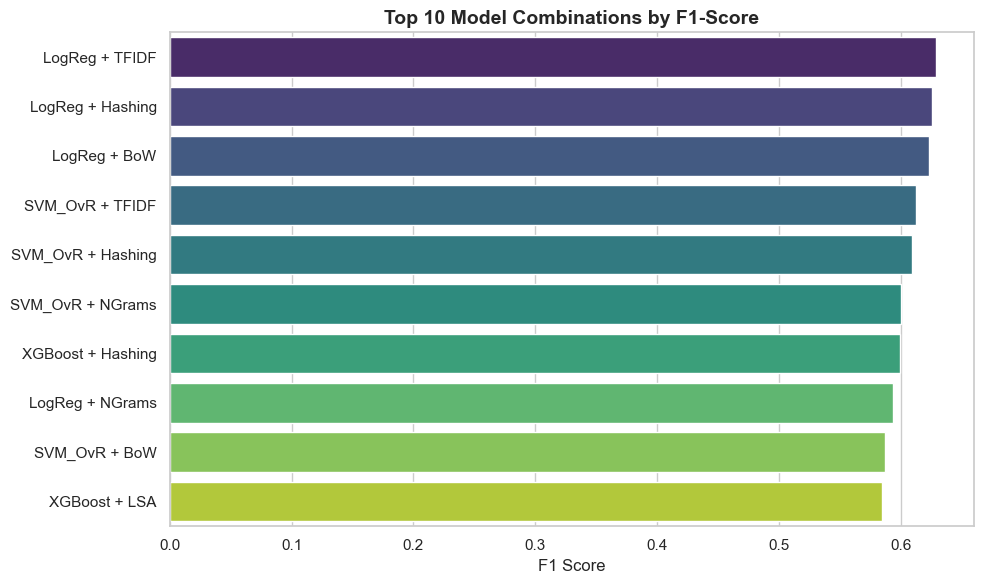

<Figure size 640x480 with 0 Axes>

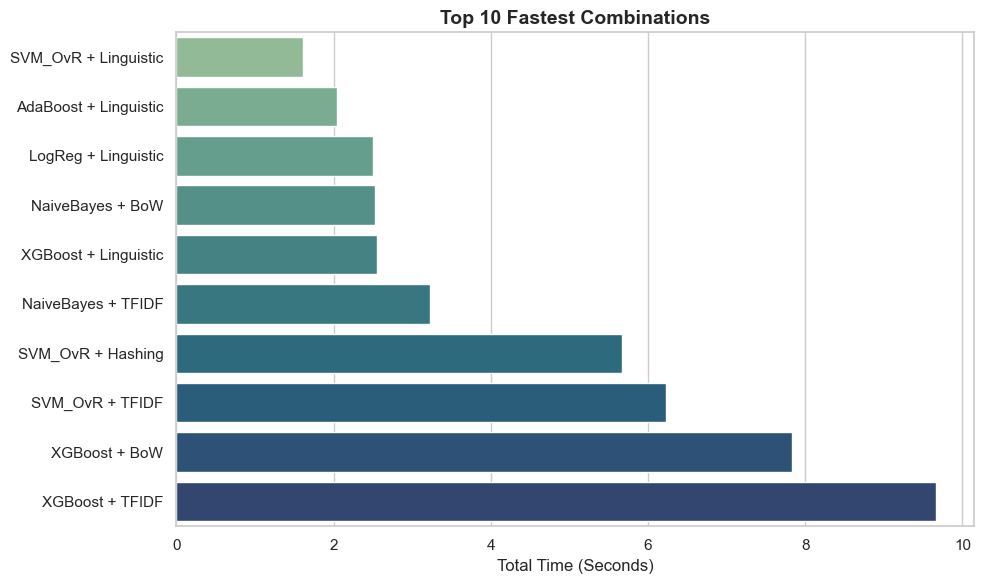

<Figure size 640x480 with 0 Axes>

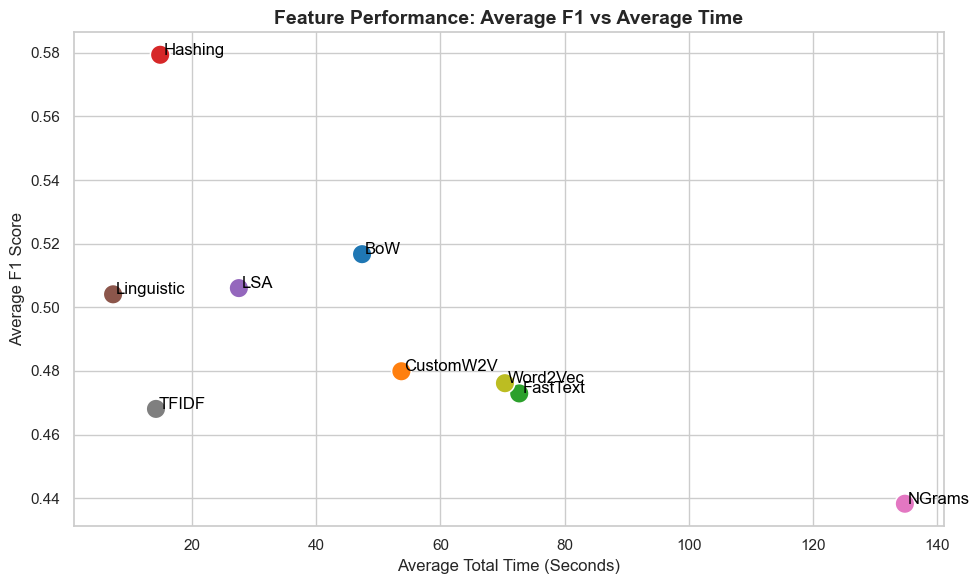

<Figure size 640x480 with 0 Axes>

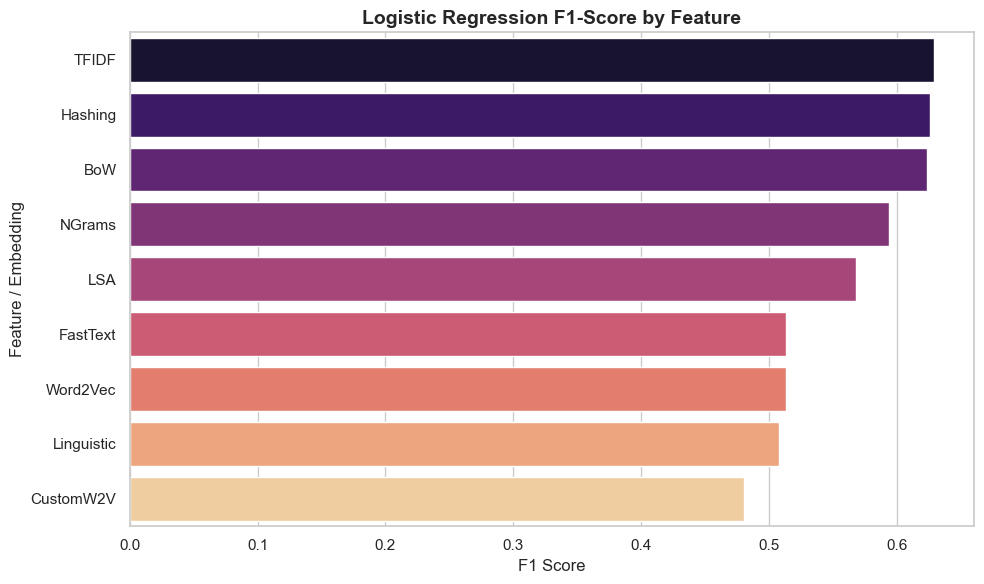

<Figure size 640x480 with 0 Axes>

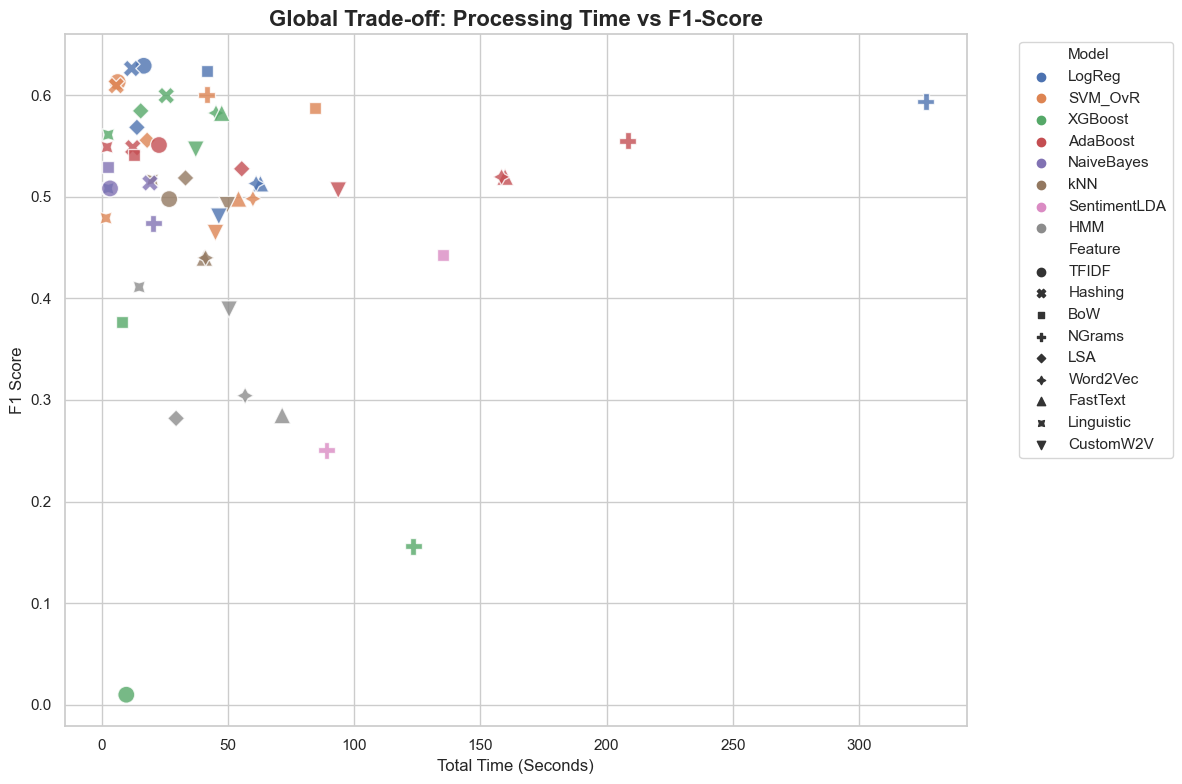

[INFO] All 5 graphs displayed and successfully saved in the 'graphs' folder!


In [6]:
def generate_pipeline_visuals(csv_filename="pipeline_results.csv"):
    if not os.path.exists(csv_filename):
        print(f"[ERROR] Could not find {csv_filename}. Run the training pipeline first!")
        return
        
    print("Loading results and generating graphs...")
    df = pd.read_csv(csv_filename)
    
    # Create a combined string column for easier labeling on the charts
    df['Combo'] = df['Model'] + " + " + df['Feature']
    
    # Set a nice, modern visual theme
    sns.set_theme(style="whitegrid")
    
    # --- NEW: Create the 'graphs' folder ---
    output_dir = "graphs"
    os.makedirs(output_dir, exist_ok=True)
    
    # ---------------------------------------------------------
    # Graph 1: Top 10 Models by F1-Score
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 6))
    top_10_f1 = df.sort_values(by='F1_Score', ascending=False).head(10)
    
    sns.barplot(data=top_10_f1, x='F1_Score', y='Combo', ax=ax, palette='viridis')
    
    ax.set_title('Top 10 Model Combinations by F1-Score', fontsize=14, fontweight='bold')
    ax.set_xlabel('F1 Score')
    ax.set_ylabel('')
    plt.tight_layout()
    
    # Save to folder, then show, then clear
    plt.savefig(os.path.join(output_dir, 'top_10_f1.png'))
    plt.show()
    plt.clf()

    # ---------------------------------------------------------
    # Graph 2: Top 10 Fastest Combinations
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 6))
    top_10_fast = df.sort_values(by='Total_Time_sec', ascending=True).head(10)
    
    sns.barplot(data=top_10_fast, x='Total_Time_sec', y='Combo', ax=ax, palette='crest')
    
    ax.set_title('Top 10 Fastest Combinations', fontsize=14, fontweight='bold')
    ax.set_xlabel('Total Time (Seconds)')
    ax.set_ylabel('')
    plt.tight_layout()
    
    plt.savefig(os.path.join(output_dir, 'top_10_fastest.png'))
    plt.show()
    plt.clf()

    # ---------------------------------------------------------
    # Graph 3: Average Embedding / Feature Trade-off
    # ---------------------------------------------------------
    feature_stats = df.groupby('Feature').agg({'F1_Score': 'mean', 'Total_Time_sec': 'mean'}).reset_index()
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.scatterplot(data=feature_stats, x='Total_Time_sec', y='F1_Score', hue='Feature', s=200, ax=ax, palette='tab10')
    ax.set_title('Feature Performance: Average F1 vs Average Time', fontsize=14, fontweight='bold')
    ax.set_xlabel('Average Total Time (Seconds)')
    ax.set_ylabel('Average F1 Score')
    
    # Add text labels right next to the scatter points
    for i in range(feature_stats.shape[0]):
        ax.text(feature_stats['Total_Time_sec'][i] + 0.5, feature_stats['F1_Score'][i], 
                feature_stats['Feature'][i], horizontalalignment='left', size='medium', color='black')
                
    if ax.get_legend() is not None:
        ax.get_legend().remove()
        
    plt.tight_layout()
    
    plt.savefig(os.path.join(output_dir, 'feature_tradeoff.png'))
    plt.show()
    plt.clf()

    # ---------------------------------------------------------
    # Graph 4: Logistic Regression Specific Performance
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 6))
    logreg_df = df[df['Model'] == 'LogReg'].sort_values(by='F1_Score', ascending=False)
    
    sns.barplot(data=logreg_df, x='F1_Score', y='Feature', ax=ax, palette='magma')
    
    ax.set_title('Logistic Regression F1-Score by Feature', fontsize=14, fontweight='bold')
    ax.set_xlabel('F1 Score')
    ax.set_ylabel('Feature / Embedding')
    plt.tight_layout()
    
    plt.savefig(os.path.join(output_dir, 'logreg_performance.png'))
    plt.show()
    plt.clf()

    # ---------------------------------------------------------
    # Graph 5: Global Trade-off Scatterplot (All Data)
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.scatterplot(data=df, x='Total_Time_sec', y='F1_Score', hue='Model', style='Feature', s=150, alpha=0.8, ax=ax)
    ax.set_title('Global Trade-off: Processing Time vs F1-Score', fontsize=16, fontweight='bold')
    ax.set_xlabel('Total Time (Seconds)')
    ax.set_ylabel('F1 Score')
    
    # Move the legend outside the plot area so it doesn't cover up your data dots
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    plt.savefig(os.path.join(output_dir, 'global_tradeoff.png'))
    plt.show()
    plt.close()

    print(f"[INFO] All 5 graphs displayed and successfully saved in the '{output_dir}' folder!")

if __name__ == "__main__":
    generate_pipeline_visuals()

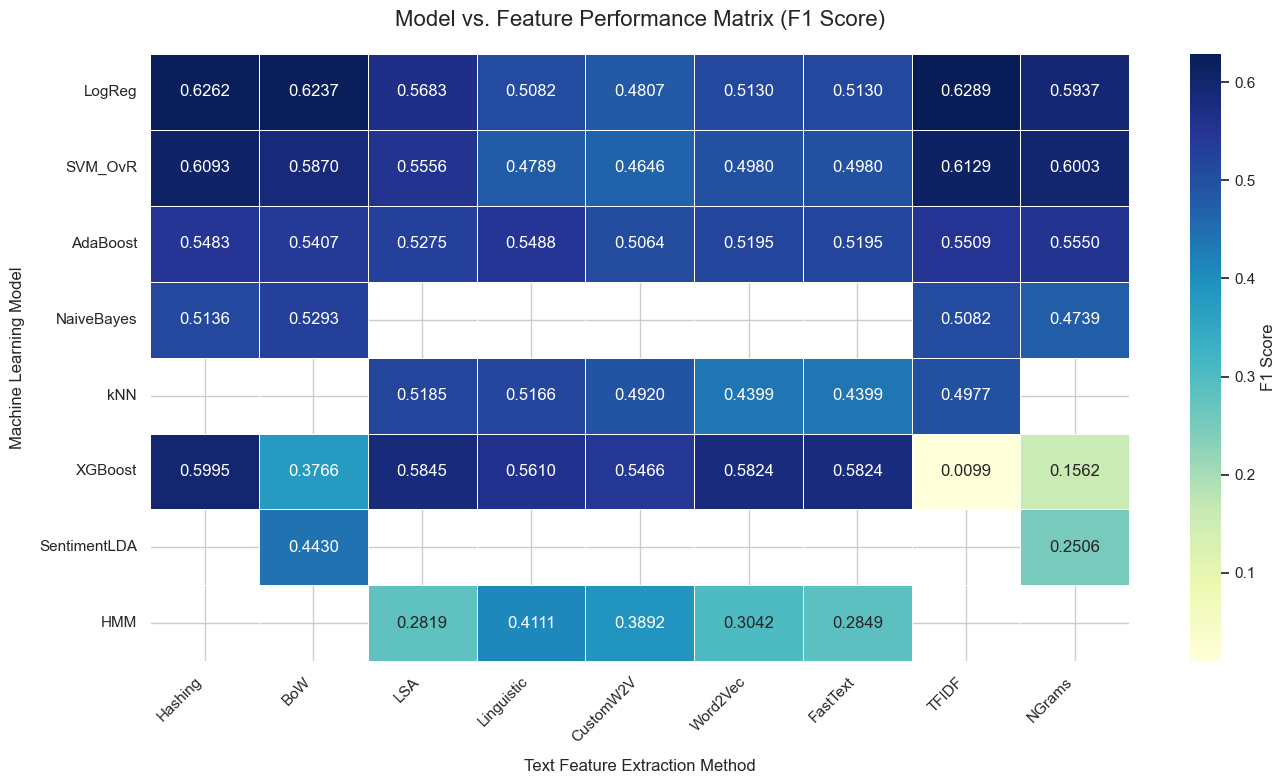

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data directly from your CSV file
df = pd.read_csv('pipeline_results.csv')

# 2. Reshape the data into a 2D Matrix
# Rows = Models, Columns = Features, Cells = F1 Score
matrix_df = df.pivot(index='Model', columns='Feature', values='F1_Score')

# 3. Sort the matrix so the best performing models and features are grouped together
# We sort by the average performance of each row and column
matrix_df = matrix_df.loc[matrix_df.mean(axis=1).sort_values(ascending=False).index]
matrix_df = matrix_df[matrix_df.mean(axis=0).sort_values(ascending=False).index]

# 4. Set up the plotting canvas
plt.figure(figsize=(14, 8))

# 5. Draw the Heatmap
sns.heatmap(
    matrix_df, 
    annot=True,          # Prints the numbers inside the boxes
    fmt=".4f",           # Formats numbers to 4 decimal places
    cmap="YlGnBu",       # The color palette (Yellow-Green-Blue). 
    linewidths=.5,       # Adds a tiny gridline between cells
    cbar_kws={'label': 'F1 Score'} # Labels the color legend
)

# 6. Clean up titles and labels for presentation
plt.title('Model vs. Feature Performance Matrix (F1 Score)', fontsize=16, pad=20)
plt.xlabel('Text Feature Extraction Method', fontsize=12, labelpad=10)
plt.ylabel('Machine Learning Model', fontsize=12, labelpad=10)

# Rotate the x-axis labels so they don't overlap
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

The script below dynamically demonstrates the "signal dilution" effect by comparing how sparse and dense machine learning architectures process the exact same social media text. It begins by training a baseline Logistic Regression model to mathematically identify the single most predictive keyword for a target class, extracting a real, multi-word tweet containing that exact trigger from your dataset. The script then contrasts the two methodologies side-by-side: it first prints the sparse logic, showing how the linear model selectively applies massive weights to the keyword while effectively zeroing out stopwords and noise. It then runs the dense Word2Vec logic, showing how mean pooling forces the sharp, extreme coordinates of the isolated keyword to be mathematically averaged with the chaotic vectors of surrounding neutral grammar. Ultimately, the code calculates the exact percentage of signal strength lost during this averaging process, empirically proving why sparse representations are superior for capturing localized intent in short text.

In [13]:
def demonstrate_full_dilution_pipeline():
    print("[INFO] Loading data and preparing models...")
    try:
        df = pd.read_csv('../data/train_data.csv').dropna(subset=['text', 'label'])
    except FileNotFoundError:
        print("Error: Could not find '../data/train_data.csv'.")
        return

    TARGET_CLASS = 3 
    MIN_WORDS = 10
    nlp = spacy.load("en_core_web_md")

    # ---------------------------------------------------------
    # PART 1: Find the Strongest Keyword
    # ---------------------------------------------------------
    print(f"\n[INFO] Finding the most representative word for Class {TARGET_CLASS}...")
    vectorizer = CountVectorizer(stop_words='english', max_features=5000)
    X_train_counts = vectorizer.fit_transform(df['text'])
    
    clf = LogisticRegression(max_iter=1000, n_jobs=-1)
    clf.fit(X_train_counts, df['label'])
    
    class_idx = list(clf.classes_).index(TARGET_CLASS)
    all_coeffs = clf.coef_[class_idx]
    vocab = vectorizer.get_feature_names_out()
    word_to_coeff = dict(zip(vocab, all_coeffs))

    top_word_idx = np.argmax(all_coeffs)
    keyword = vocab[top_word_idx]
    
    print(f" -> The Logistic Regression model found that '{keyword.upper()}' is the #1 strongest predictor!")

    # ---------------------------------------------------------
    # PART 2: Extract the proper tweet
    # ---------------------------------------------------------
    matches = df[(df['label'] == TARGET_CLASS) & 
                 (df['text'].str.contains(r'\b' + keyword + r'\b', case=False, regex=True))].copy()
    matches['word_count'] = matches['text'].apply(lambda x: len(str(x).split()))
    long_enough = matches[matches['word_count'] >= MIN_WORDS]
    
    if long_enough.empty:
        real_tweet = matches.sort_values('word_count').iloc[0]['text']
    else:
        real_tweet = long_enough.sort_values('word_count').iloc[0]['text']

    print("\n" + "="*80)
    print(f"EXTRACTED TWEET (Class {TARGET_CLASS}, Word Count: {len(real_tweet.split())}):")
    print(f"\"{real_tweet}\"")
    print("="*80)

    # ---------------------------------------------------------
    # PART 3: SPARSE LOGIC (LogReg Coefficients)
    # ---------------------------------------------------------
    print("\n[ 1. SPARSE REPRESENTATION: LOGREG VIEW ]")
    print("Notice how LogReg mathematically ignores neutral words (0.0000) to isolate the keyword.")
    print(f"{'WORD':<15} | {'LOGREG WEIGHT':<15} | {'ROLE'}")
    print("-" * 55)
    
    words_in_tweet = re.findall(r'\b\w+\b', real_tweet.lower())
    
    for word in words_in_tweet:
        coeff = word_to_coeff.get(word, 0.0) 
        if word == keyword.lower():
            role = "KEY TRIGGER"
        elif coeff == 0.0:
            role = "IGNORED (Stopword/Noise)"
        elif coeff < 0:
            role = "NEGATIVE EVIDENCE"
        else:
            role = "MINOR CONTEXT"
            
        print(f"{word:<15} | {coeff:>15.4f} | {role}")

    # ---------------------------------------------------------
    # PART 4: DENSE LOGIC (Word2Vec Arrays)
    # ---------------------------------------------------------
    print("\n[ 2. DENSE REPRESENTATION: WORD2VEC VIEW ]")
    print("Showing the first 5 dimensions of each word's 300-dimension vector:")
    
    doc = nlp(real_tweet)
    valid_vectors = []
    keyword_vector = None
    
    for token in doc:
        if not token.is_alpha:
            continue
            
        vec_slice = np.round(token.vector[:5], 3)
        valid_vectors.append(token.vector) 
        
        if token.text.lower() == keyword.lower():
            keyword_vector = np.round(token.vector[:5], 3)
            print(f" -> {token.text.upper():<12}: {vec_slice} <--- SHARP COORDINATES")
        else:
            print(f"    {token.text:<12}: {vec_slice}")

    # ---------------------------------------------------------
    # PART 5: Mean Pooling Calculation
    # ---------------------------------------------------------
    print("\n[ 3. THE MEAN POOLING DILUTION ]")
    print("Calculating the mathematical average of all vectors...")
    
    final_tweet_vector = np.mean(valid_vectors, axis=0)
    final_slice = np.round(final_tweet_vector[:5], 3)
    
    print(f"\n -> ORIGINAL KEYWORD VECTOR: {keyword_vector}")
    print(f" -> FINAL AVERAGED VECTOR:   {final_slice}")
    
    # Calculate loss based on the first dimension (Dim 0)
    k_val = keyword_vector[0]
    f_val = final_slice[0]
    
    # Prevent division by zero if Dim 0 happens to be exactly 0
    if k_val != 0:
        loss = (1 - abs(f_val / k_val)) * 100
        print(f"\nSIGNAL STRENGTH LOSS (Dim 0): {loss:.1f}%")
        print(f"Interpretation: In a {len(words_in_tweet)}-word tweet, the mean pooling math")
        print(f"divides the impact of '{keyword.upper()}' by the total word count,")
        print("effectively hiding the needle in a haystack of neutral grammar.")

if __name__ == "__main__":
    demonstrate_full_dilution_pipeline()

[INFO] Loading data and preparing models...

[INFO] Finding the most representative word for Class 3...
 -> The Logistic Regression model found that 'YAY' is the #1 strongest predictor!

EXTRACTED TWEET (Class 3, Word Count: 12):
"yay virginia!! blue_heart blue_heart blue_heart my state started it by cheating chile"

[ 1. SPARSE REPRESENTATION: LOGREG VIEW ]
Notice how LogReg mathematically ignores neutral words (0.0000) to isolate the keyword.
WORD            | LOGREG WEIGHT   | ROLE
-------------------------------------------------------
yay             |          2.1903 | KEY TRIGGER
virginia        |          0.3053 | MINOR CONTEXT
blue_heart      |          0.9498 | MINOR CONTEXT
blue_heart      |          0.9498 | MINOR CONTEXT
blue_heart      |          0.9498 | MINOR CONTEXT
my              |          0.0000 | IGNORED (Stopword/Noise)
state           |         -0.5206 | NEGATIVE EVIDENCE
started         |          0.1079 | MINOR CONTEXT
it              |          0.0000 | IGNOR